# 1.5 Featured Data — Model Training

Train, compare, and select the best regression model for house price prediction.

**Steps:**
1. Load feature-ready data
2. Train/test split
3. Configure MLflow Tracking
4. Define evaluation metrics
5. Train multiple models and compare
6. Cross-validation on top models
7. Hyperparameter tuning for best model
8. Log best model to MLflow
9. Save best model and experiment results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import time
import warnings
import mlflow

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.5.1 Load Feature-Ready Data

In [2]:
df_train = pd.read_csv('../data/data_feature_train.csv')

with open('../artifacts/preprocessing/data_features.json', 'r') as f:
    FEATURE_COLS = json.load(f)

X_train = df_train[FEATURE_COLS]
y_train = df_train['log_price']
y_train_orig = df_train['price']

print(f'Train feature matrix: {X_train.shape}')
print(f'Features: {FEATURE_COLS}')


Train feature matrix: (67, 17)
Features: ['sqft', 'bedrooms', 'bathrooms', 'year_built', 'house_age', 'loc_Downtown', 'loc_Mountain', 'loc_Rural', 'loc_Suburb', 'loc_Urban', 'loc_Waterfront', 'condition_encoded', 'total_rooms', 'bath_bed_ratio', 'is_luxury', 'is_new', 'sqft_per_bedroom']


## 1.5.2 Training Data (CV-based Model Selection)

The model is trained on the full train split (67 rows from notebook 1_1).
Model selection uses **5-fold cross-validation** on the training data only.

The held-out test split is **not** loaded here: notebook 1_6 applies the saved
configuration (`artifacts/preprocessing/data_features.json` + `data_scaler.json`)
to `data_raw_test.csv` and reports the final held-out metrics.


In [3]:
print(f'Training set: {X_train.shape[0]} samples')
print(f'\nTarget distribution:')
print(f'  Train - mean: ${np.expm1(y_train).mean():,.0f}, std: ${np.expm1(y_train).std():,.0f}')


Training set: 67 samples

Target distribution:
  Train - mean: $627,097, std: $329,535


## 1.5.3 Configure MLflow Tracking


In [5]:
mlflow.set_tracking_uri('http://localhost:5555')
mlflow.set_experiment('house_price_prediction')


<Experiment: artifact_location='/mlflow/artifacts/1', creation_time=1785987788652, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785987788652, lifecycle_stage='active', name='house_price_prediction', tags={}, trace_location=None, workspace='default'>

## 1.5.4 Define Evaluation Metrics

In [6]:
def evaluate_model(model, X_train, y_train, model_name="Model", cv=5):
    y_pred_train_log = model.predict(X_train)

    y_pred_train = np.expm1(y_pred_train_log)
    y_train_orig_local = np.expm1(y_train)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

    metrics = {
        'Model': model_name,
        'Train_R2': r2_score(y_train_orig_local, y_pred_train),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train_orig_local, y_pred_train)),
        'Train_MAE': mean_absolute_error(y_train_orig_local, y_pred_train),
        'Train_MAPE': mean_absolute_percentage_error(y_train_orig_local, y_pred_train),
        'CV_R2': cv_scores.mean(),
        'CV_R2_std': cv_scores.std(),
    }
    return metrics

def print_metrics(metrics):
    print(f"\n{'='*50}")
    print(f"Model: {metrics['Model']}")
    print(f"{'='*50}")
    print(f"  Train R2:   {metrics['Train_R2']:.4f}")
    print(f"  CV R2:      {metrics['CV_R2']:.4f} (+/- {metrics['CV_R2_std']:.4f})")
    print(f"  Train RMSE: ${metrics['Train_RMSE']:>12,.2f}")
    print(f"  Train MAE:  ${metrics['Train_MAE']:>12,.2f}")
    print(f"  Train MAPE: {metrics['Train_MAPE']:.4f}")


## 1.5.5 Train Baseline: Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_metrics = evaluate_model(lr, X_train, y_train, "Linear Regression")
print_metrics(lr_metrics)



Model: Linear Regression
  Train R2:   0.9974
  CV R2:      0.9963 (+/- 0.0012)
  Train RMSE: $   16,737.95
  Train MAE:  $   11,245.28
  Train MAPE: 0.0163


## 1.5.6 Train Multiple Models

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'SVR': SVR(kernel='rbf', C=100, epsilon=0.1),
}

all_metrics = []

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        mlflow.set_tag("model_type", name)
        start_time = time.time()
        mlflow.log_params({k: str(v) for k, v in model.get_params().items()})
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        metrics = evaluate_model(model, X_train, y_train, name)
        metrics["Train_Time(s)"] = round(train_time, 3)
        mlflow.log_metrics({
            "train_r2": metrics["Train_R2"],
            "cv_r2": metrics["CV_R2"],
            "train_rmse": metrics["Train_RMSE"],
            "train_mae": metrics["Train_MAE"],
            "train_mape": metrics["Train_MAPE"],
            "train_time": metrics["Train_Time(s)"],
        })
        all_metrics.append(metrics)
        print(f'{name:25s} | CV R2: {metrics["CV_R2"]:.4f} | Train R2: {metrics["Train_R2"]:.4f} | Time: {train_time:.3f}s')


Linear Regression         | CV R2: 0.9963 | Train R2: 0.9974 | Time: 0.066s
🏃 View run Linear Regression at: http://localhost:5555/#/experiments/1/runs/a4b6c068165f4ae1a843d5e89dc95289
🧪 View experiment at: http://localhost:5555/#/experiments/1
Ridge                     | CV R2: 0.9876 | Train R2: 0.9879 | Time: 0.068s
🏃 View run Ridge at: http://localhost:5555/#/experiments/1/runs/fb19b01ee02f443392f24f363b13ed0d
🧪 View experiment at: http://localhost:5555/#/experiments/1
Lasso                     | CV R2: 0.9623 | Train R2: 0.9589 | Time: 0.067s
🏃 View run Lasso at: http://localhost:5555/#/experiments/1/runs/b043699fb4984806a36557ddf143a96a
🧪 View experiment at: http://localhost:5555/#/experiments/1
ElasticNet                | CV R2: 0.9756 | Train R2: 0.9729 | Time: 0.065s
🏃 View run ElasticNet at: http://localhost:5555/#/experiments/1/runs/822715c2adc5457fa54794b7c5f088af
🧪 View experiment at: http://localhost:5555/#/experiments/1
Random Forest             | CV R2: 0.9966 | Train R

In [9]:
results_df = pd.DataFrame(all_metrics)
results_df = results_df.sort_values('CV_R2', ascending=False)
results_df[['Model', 'Train_R2', 'CV_R2', 'Train_RMSE', 'Train_MAE', 'Train_MAPE', 'Train_Time(s)']].round(4)


,Model,Train_R2,CV_R2,Train_RMSE,Train_MAE,Train_MAPE,Train_Time(s)
5,Gradient Boosting,0.9999,0.9967,2751.4496,1529.0158,0.0029,0.110
4,Random Forest,0.9995,0.9966,7432.4571,5230.8982,0.0090,0.316
0,Linear Regression,0.9974,0.9963,16737.9507,11245.2822,0.0163,0.066
1,Ridge,0.9879,0.9876,35988.7534,23174.2774,0.0302,0.068
3,ElasticNet,0.9729,0.9756,53832.2015,34790.2815,0.0470,0.065
2,Lasso,0.9589,0.9623,66276.2007,43897.5209,0.0622,0.067
6,SVR,0.8451,0.8831,128737.2205,84845.9915,0.1176,0.066


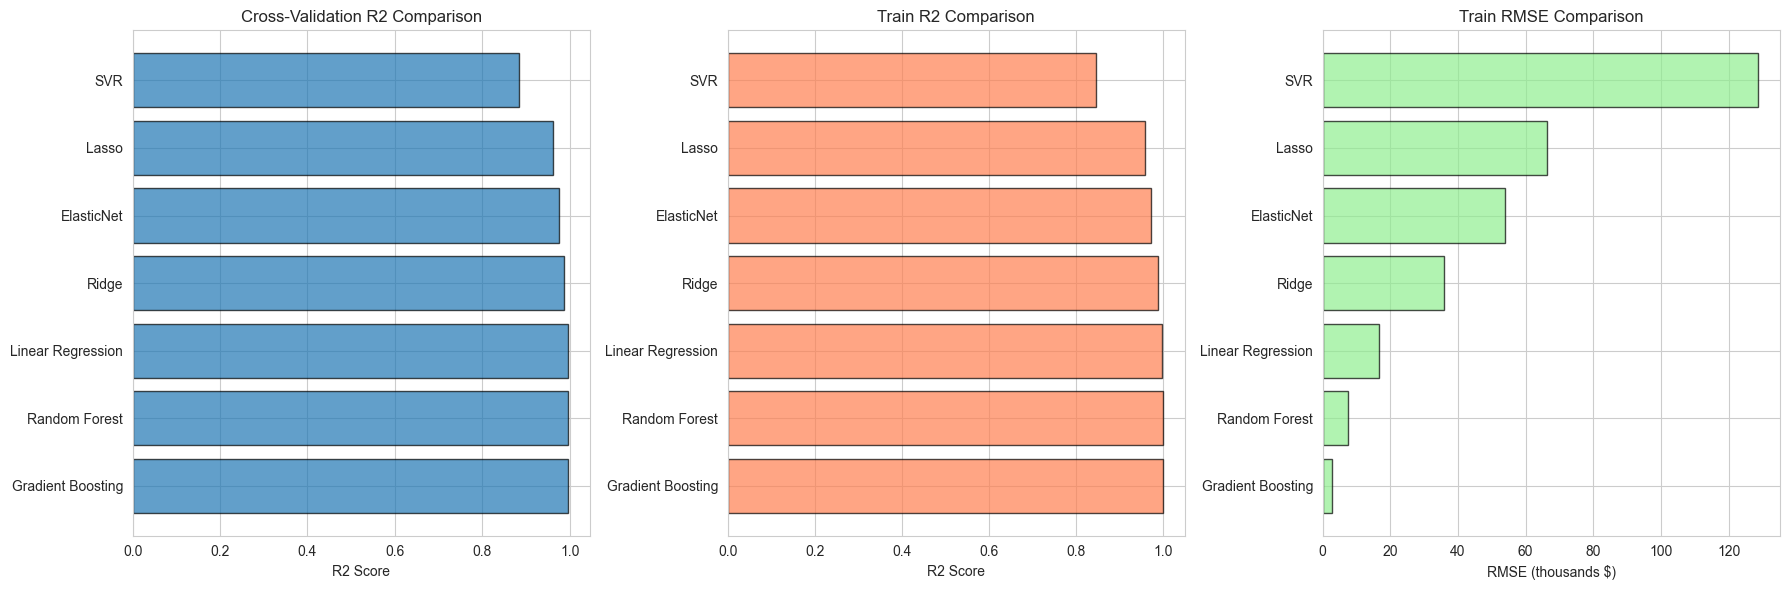

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_names = results_df['Model'].values
x_pos = np.arange(len(models_names))

axes[0].barh(x_pos, results_df['CV_R2'].values, edgecolor='black', alpha=0.7)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(models_names)
axes[0].set_xlabel('R2 Score')
axes[0].set_title('Cross-Validation R2 Comparison')

axes[1].barh(x_pos, results_df['Train_R2'].values, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(models_names)
axes[1].set_xlabel('R2 Score')
axes[1].set_title('Train R2 Comparison')

axes[2].barh(x_pos, results_df['Train_RMSE'].values / 1000, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].set_yticks(x_pos)
axes[2].set_yticklabels(models_names)
axes[2].set_xlabel('RMSE (thousands $)')
axes[2].set_title('Train RMSE Comparison')

plt.tight_layout()
plt.show()


## 1.5.7 Cross-Validation on Top Models

Cross-validating top 3 models: ['Gradient Boosting' 'Random Forest' 'Linear Regression']

Gradient Boosting         | CV R2: 0.9967 (+/- 0.0022)
Random Forest             | CV R2: 0.9966 (+/- 0.0023)
Linear Regression         | CV R2: 0.9963 (+/- 0.0012)


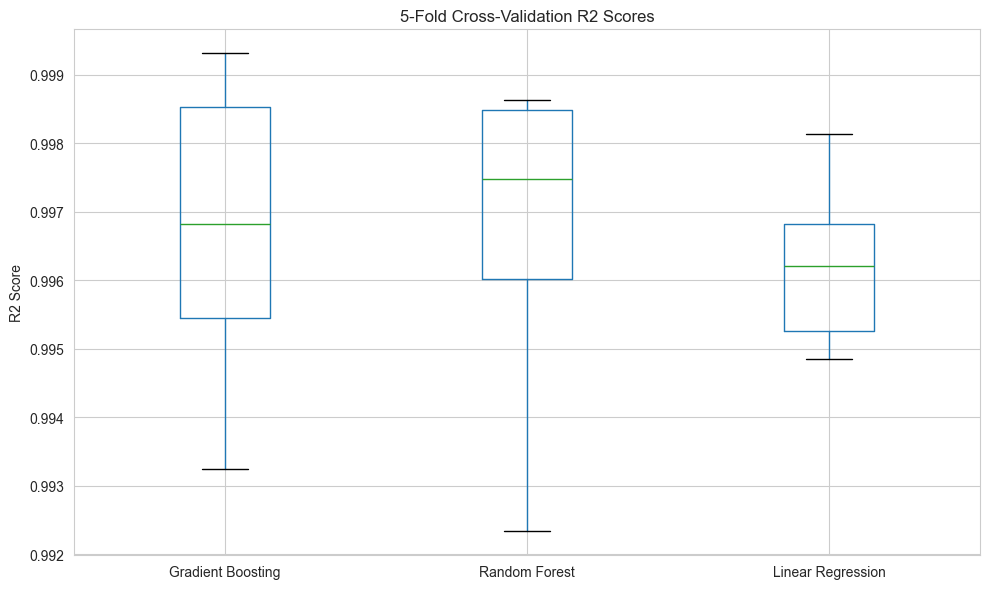

In [11]:
top_models = results_df.head(3)['Model'].values
print(f'Cross-validating top 3 models: {top_models}\n')

cv_results = {}
for name in top_models:
    model = models[name]
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | CV R2: {scores.mean():.4f} (+/- {scores.std():.4f})')

cv_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(10, 6))
cv_df.boxplot(ax=ax)
ax.set_title('5-Fold Cross-Validation R2 Scores')
ax.set_ylabel('R2 Score')
plt.tight_layout()
plt.show()

## 1.5.8 Hyperparameter Tuning — Best Model

In [12]:
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Best model from CV: {best_model_name}')

Best model from CV: Gradient Boosting


In [13]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'min_samples_split': [2, 5, 10]
    },
    'Ridge': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    'Linear Regression': {},
    'ElasticNet': {
        'alpha': [0.001, 0.01, 0.1, 1.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR': {
        'C': [1, 10, 100, 1000],
        'epsilon': [0.01, 0.1, 0.5],
        'kernel': ['rbf', 'linear']
    }
}

if param_grids.get(best_model_name):
    print(f'Running GridSearchCV for {best_model_name}...')
    grid_search = GridSearchCV(
        models[best_model_name],
        param_grids[best_model_name],
        cv=5, scoring='r2', n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)
    print(f'\nBest parameters: {grid_search.best_params_}')
    print(f'Best CV R2: {grid_search.best_score_:.4f}')
    best_model = grid_search.best_estimator_
else:
    print(f'No hyperparameter grid for {best_model_name}. Using default params.')
    best_model = models[best_model_name]

Running GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R2: 0.9982


## 1.5.9 Log Best Model to MLflow


In [14]:
with mlflow.start_run(run_name=f"Best_{best_model_name}"):
    mlflow.set_tag("model_type", best_model_name)
    mlflow.set_tag("is_best", "true")
    if param_grids.get(best_model_name):
        mlflow.log_params({k: str(v) for k, v in grid_search.best_params_.items()})
    best_metrics = evaluate_model(best_model, X_train, y_train, best_model_name)
    best_cv_r2 = float(grid_search.best_score_) if param_grids.get(best_model_name) else float(cv_results[best_model_name].mean())
    mlflow.log_metrics({
        "train_r2": best_metrics["Train_R2"],
        "cv_r2": best_cv_r2,
        "train_rmse": best_metrics["Train_RMSE"],
        "train_mae": best_metrics["Train_MAE"],
        "train_mape": best_metrics["Train_MAPE"],
    })
    mlflow.sklearn.log_model(best_model, "model")


2026/08/12 21:53:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Best_Gradient Boosting at: http://localhost:5555/#/experiments/1/runs/02ccd076a7e34c52bb07190aa349cf61
🧪 View experiment at: http://localhost:5555/#/experiments/1


## 1.5.10 Save Best Model and Experiment Results

In [15]:
models_dir = '../artifacts/models'
experiments_dir = '../artifacts/experiments'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(experiments_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'best_model.joblib')
joblib.dump(best_model, model_path)
print(f'Saved best model to {model_path}')

experiment_results = {
    'best_model': best_model_name,
    'best_params': grid_search.best_params_ if param_grids.get(best_model_name) else {},
    'best_cv_r2': float(grid_search.best_score_) if param_grids.get(best_model_name) else float(cv_results[best_model_name].mean()),
    'final_metrics': best_metrics,  # train metrics; held-out test metrics are added in 1_6
    'all_model_results': all_metrics,
    'features_used': FEATURE_COLS,
    'target': 'log_price (log-transformed)',
    'train_samples': int(X_train.shape[0]),
    'note': 'Held-out test metrics are computed in notebook 1_6 and appended as test_metrics.'
}

results_path = os.path.join(experiments_dir, 'experiment_results.json')
with open(results_path, 'w') as f:
    json.dump(experiment_results, f, indent=2, default=str)
print(f'Saved experiment results to {results_path}')


Saved best model to ../artifacts/models\best_model.joblib
Saved experiment results to ../artifacts/experiments\experiment_results.json
